# Multiscale response similarity

## Scientific question

When two transcriptomic responses appear similar, **at what biological resolution are they actually similar?**

This benchmark integrates five existing, frozen views of a treatment-minus-control response: conventional expression, the global BridgeRNA sample embedding, Hallmark/program response, gene attribution, and the contextual-gene graph. It preserves every component separately and does not retrain BridgeRNA or invent missing measurements.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT / 'benchmarks/multiscale_response_similarity'
R = ROOT / 'results'
pd.set_option('display.max_colwidth', 100)
profiles = pd.read_csv(R / 'pairwise_profiles/multiscale_pairwise_profiles.csv')
primary = pd.read_csv(R / 'summary/primary_table.csv')
inventory = pd.read_csv(R / 'summary/compatibility_inventory.csv')
provenance = json.loads((R / 'summary/provenance.json').read_text())

## Data compatibility audit

Only pairs of treatment-control responses can populate the five-scale profile. Controlled T-cell PolyA/Ribo is one controlled technical displacement, while ARCHS4/recount3 comprises same-sample processing pairs; neither is silently converted into a response-pair comparison. Other Task 3 contrasts remain incomplete because matched Hallmark, IG, and graph-response components were not previously computed.

In [2]:
display(inventory)

,dataset,unit,profiles,five_scale_compatible,role
0,RR1/RR3,response-pair,4,4,held-out stress cases
1,exercise,response-pair,28,28,prespecified biological relationships
2,controlled T-cell PolyA/Ribo,single controlled technical response,1,0,technical reference; not a response-pair
3,ARCHS4/recount3,same-sample processing pair,574,0,sample-level processing control; no treatment-control response
4,other Task 3 spaceflight,biological response,10,0,missing matched Hallmark/IG/graph components


## Metric definitions

- **Expression:** cosine between established conventional response vectors.
- **Global BridgeRNA:** cosine between frozen sample-embedding response vectors.
- **Hallmark/program:** cosine between established Hallmark module responses.
- **Attribution:** signed IG-response cosine. Exercise uses the saved signed Top-250 IG vectors and is explicitly labeled as truncated.
- **Contextual graph:** signed weighted-edge response similarity from the validated frozen layer-12, union-kNN graph (`k=10`).

Raw values are retained. Within-domain percentile ranks are used only to place unlike metric scales on common visual axes.

## Primary RR1/RR3 stress cases

In [3]:
display(primary.style.format({c: '{:.3f}' for c in ['expression','global_bridgerna','hallmark_program','attribution','contextual_graph']}))

,comparison,relationship_type,expression,global_bridgerna,hallmark_program,attribution,contextual_graph,interpretation
0,RR1 OSD-48 original ↔ OSD-168 remeasurement,technically_sensitive_remeasurement,0.369,-0.807,-0.424,-0.635,0.183,multiscale_disagreement_or_ambiguous
1,RR3-39 OSD-137 original ↔ OSD-168 remeasurement,true_technical_remeasurement,0.652,0.790,0.775,0.775,0.319,multiscale_agreement
2,RR3-40 OSD-137 original ↔ OSD-168 remeasurement,true_technical_remeasurement,0.822,0.917,0.922,0.858,0.399,multiscale_agreement
3,RR1 original ↔ RR3-39 original,unrelated_false_friend,0.121,0.811,0.510,0.258,0.012,global_convergence / molecular_divergence


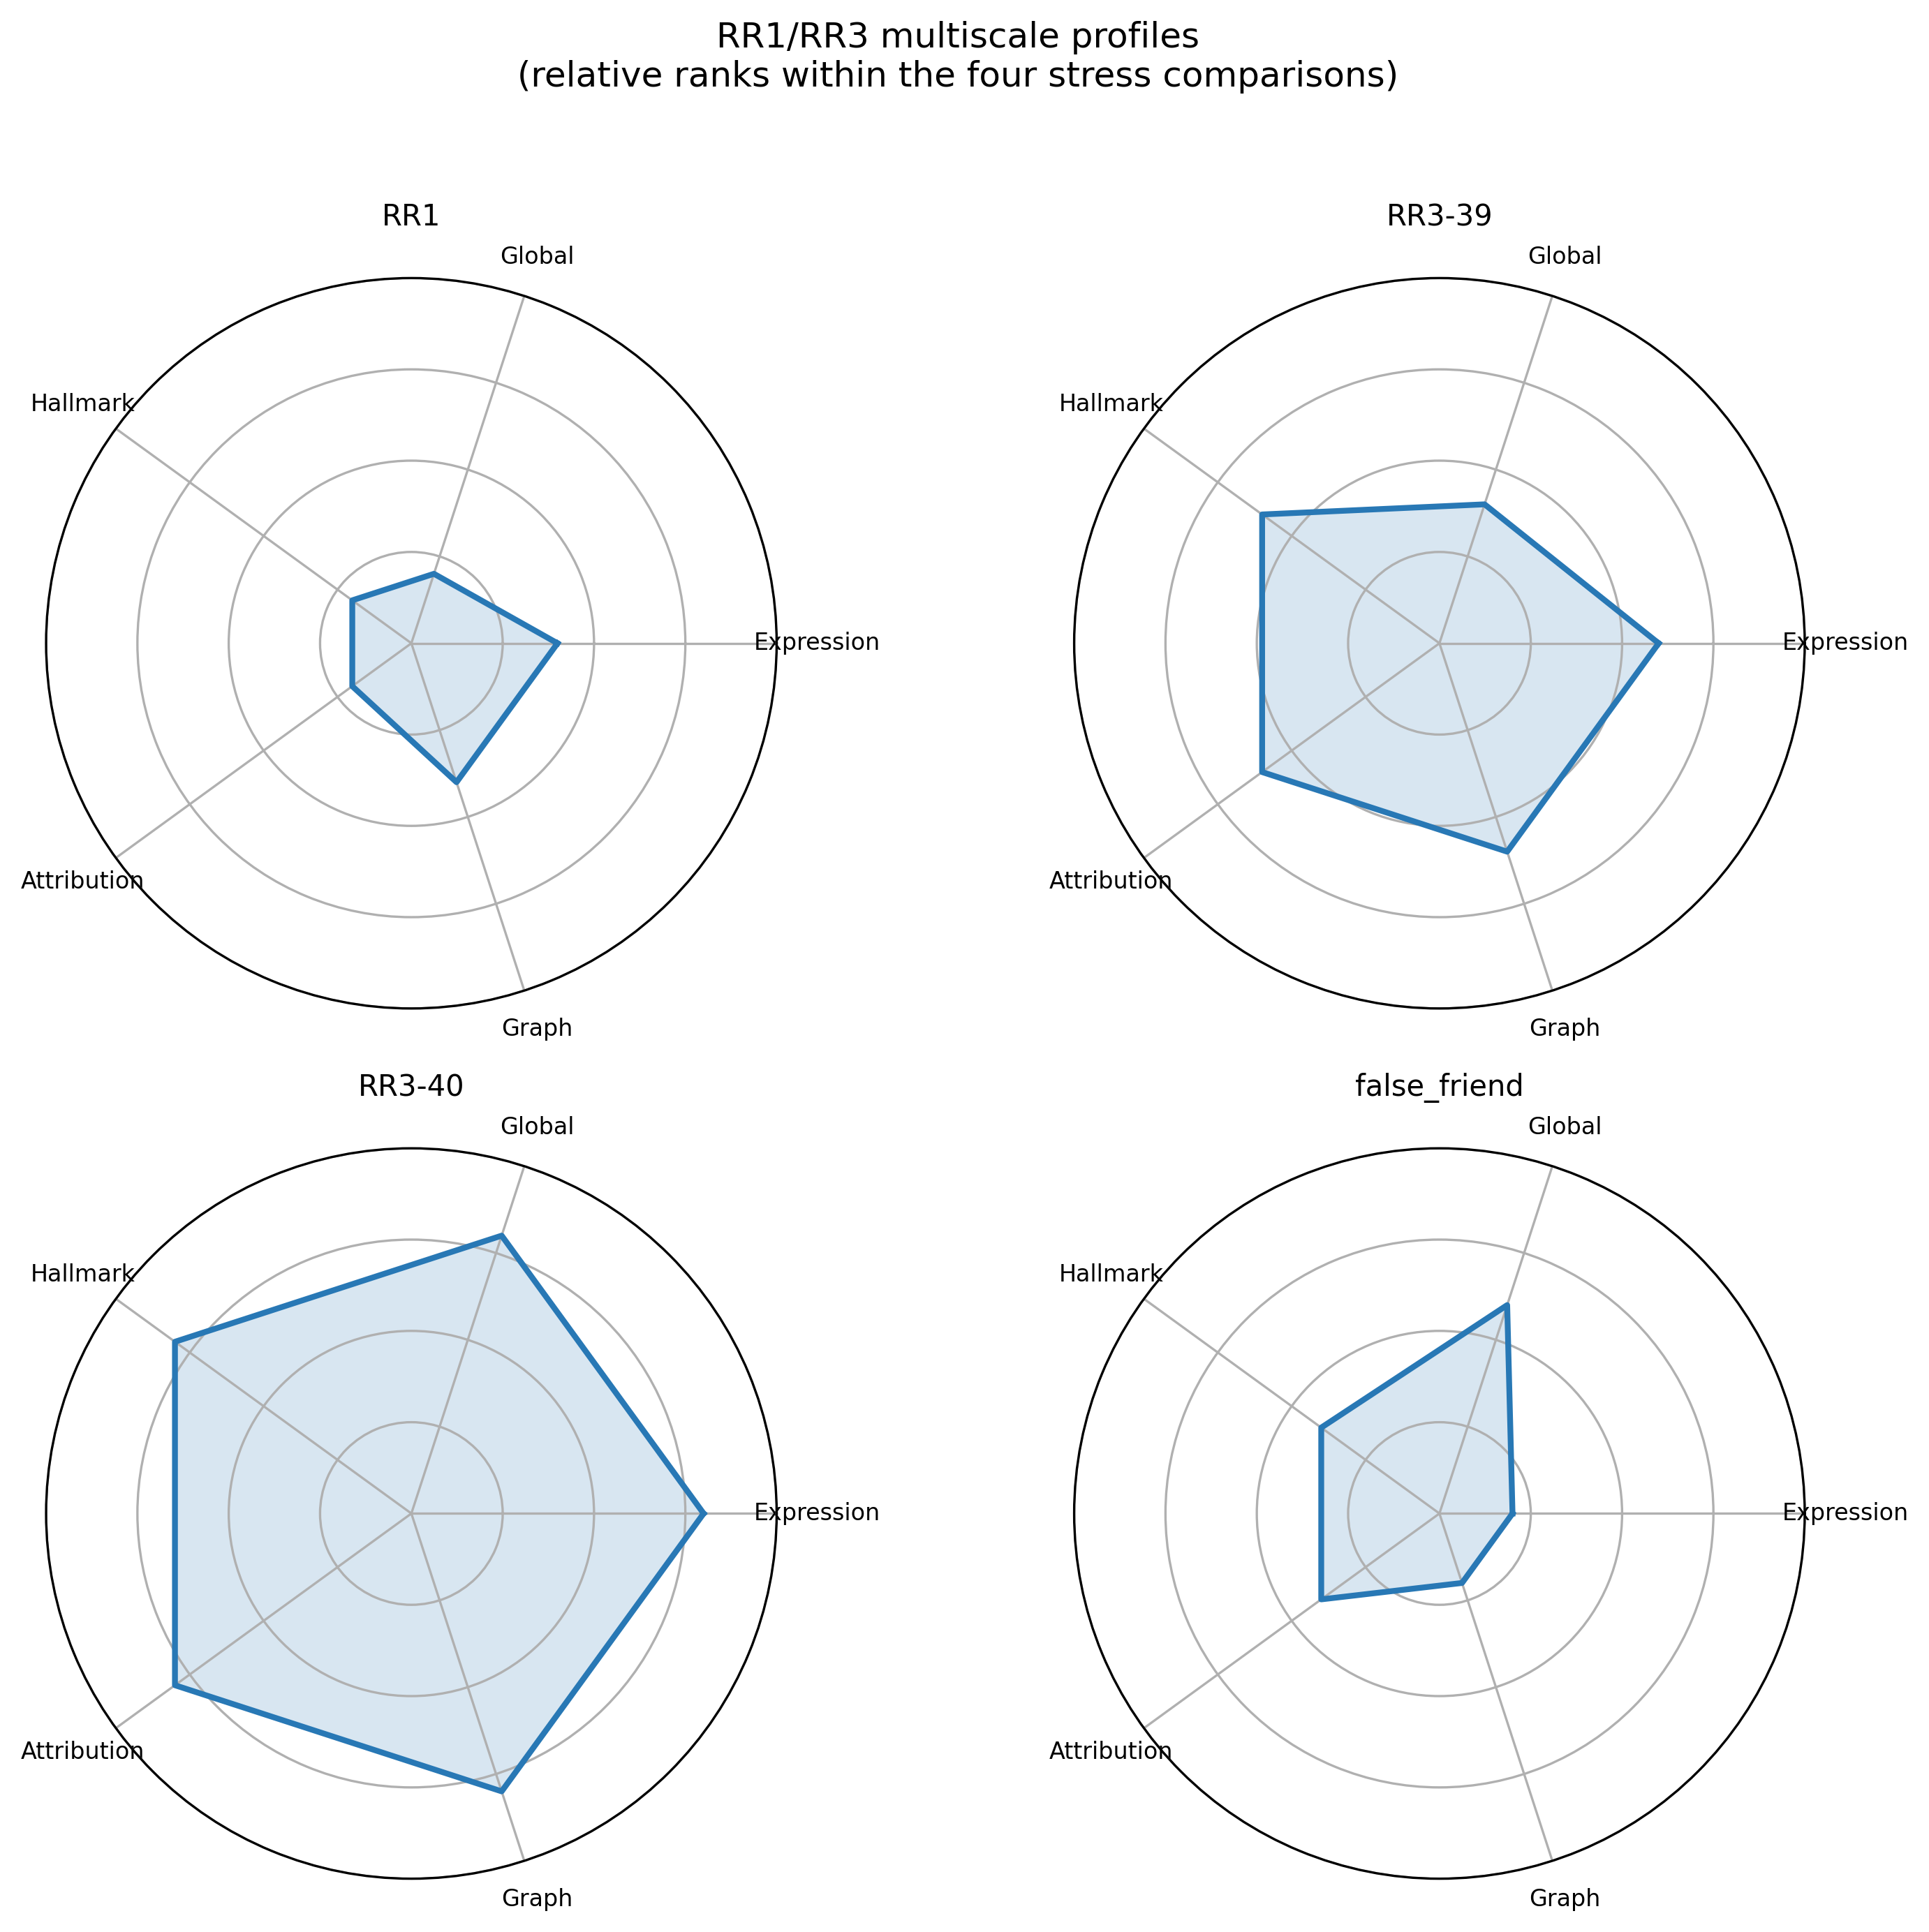

In [4]:
display(Image(filename=str(R / 'figures/rr1_rr3_profiles.png')))

### What the stress cases show

- **RR3-40** is concordant at every scale and is the strongest true technical remeasurement.
- **RR3-39** is also positive at every scale, although agreement is weaker than RR3-40.
- **RR1 remeasurement** is not merely a global-geometry failure: global, program, and attribution responses reverse or disagree, while expression and graph retain only partial positive agreement. This is deeper multiscale technical sensitivity.
- **RR1↔RR3-39 false friend** has high global cosine (0.811), but weak expression (0.121), modest program/attribution agreement, and near-zero graph agreement (0.012). Global similarity alone therefore overstates molecular agreement.

## Global versus contextual-relational agreement

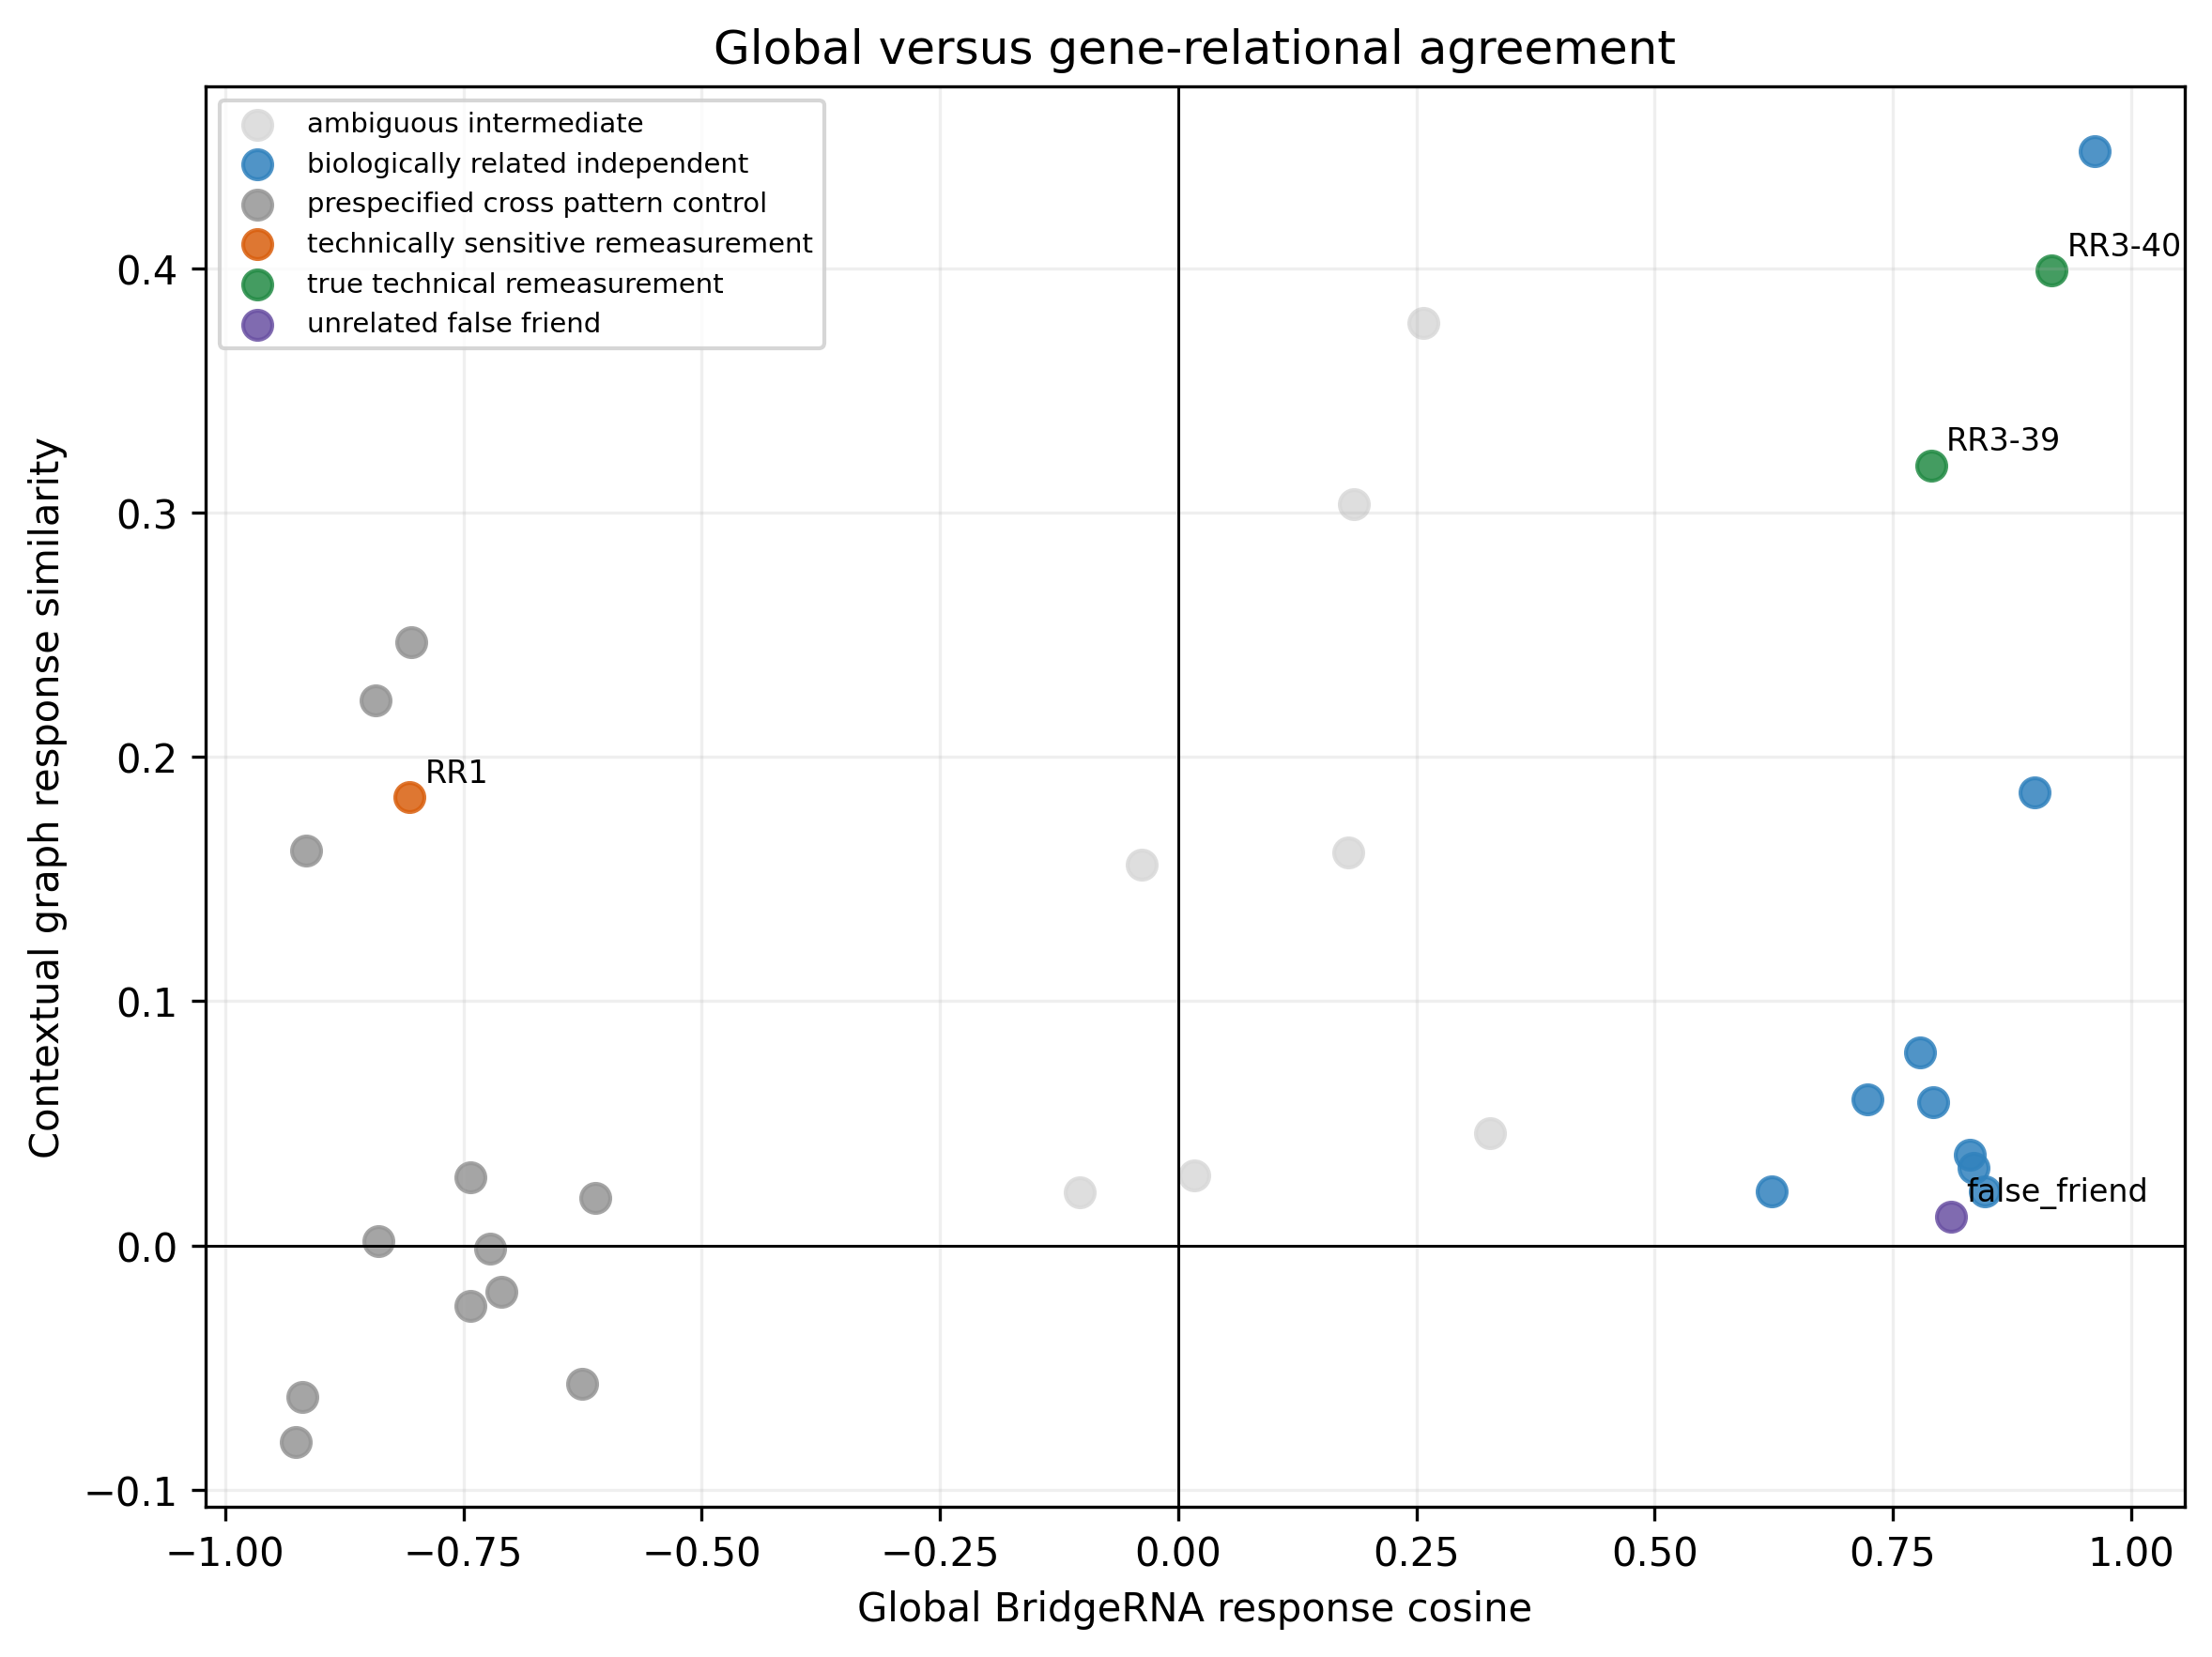

In [5]:
display(Image(filename=str(R / 'figures/global_vs_graph.png')))

## Exercise response profiles

The eight established exercise contrasts contribute 28 prespecified pairwise comparisons. Within the previously frozen A/B groupings, same-pattern pairs are treated as biologically related; cross-pattern pairs are controls; comparisons involving the intermediate study remain ambiguous. These labels are inherited and were not fit here.

In [6]:
exercise = profiles[profiles.domain.eq('exercise')]
summary = (exercise.groupby('relationship_type')[['expression','global_bridgerna','hallmark_program','attribution','contextual_graph']]
           .agg(['mean','median','count']))
display(summary.style.format('{:.3f}'))

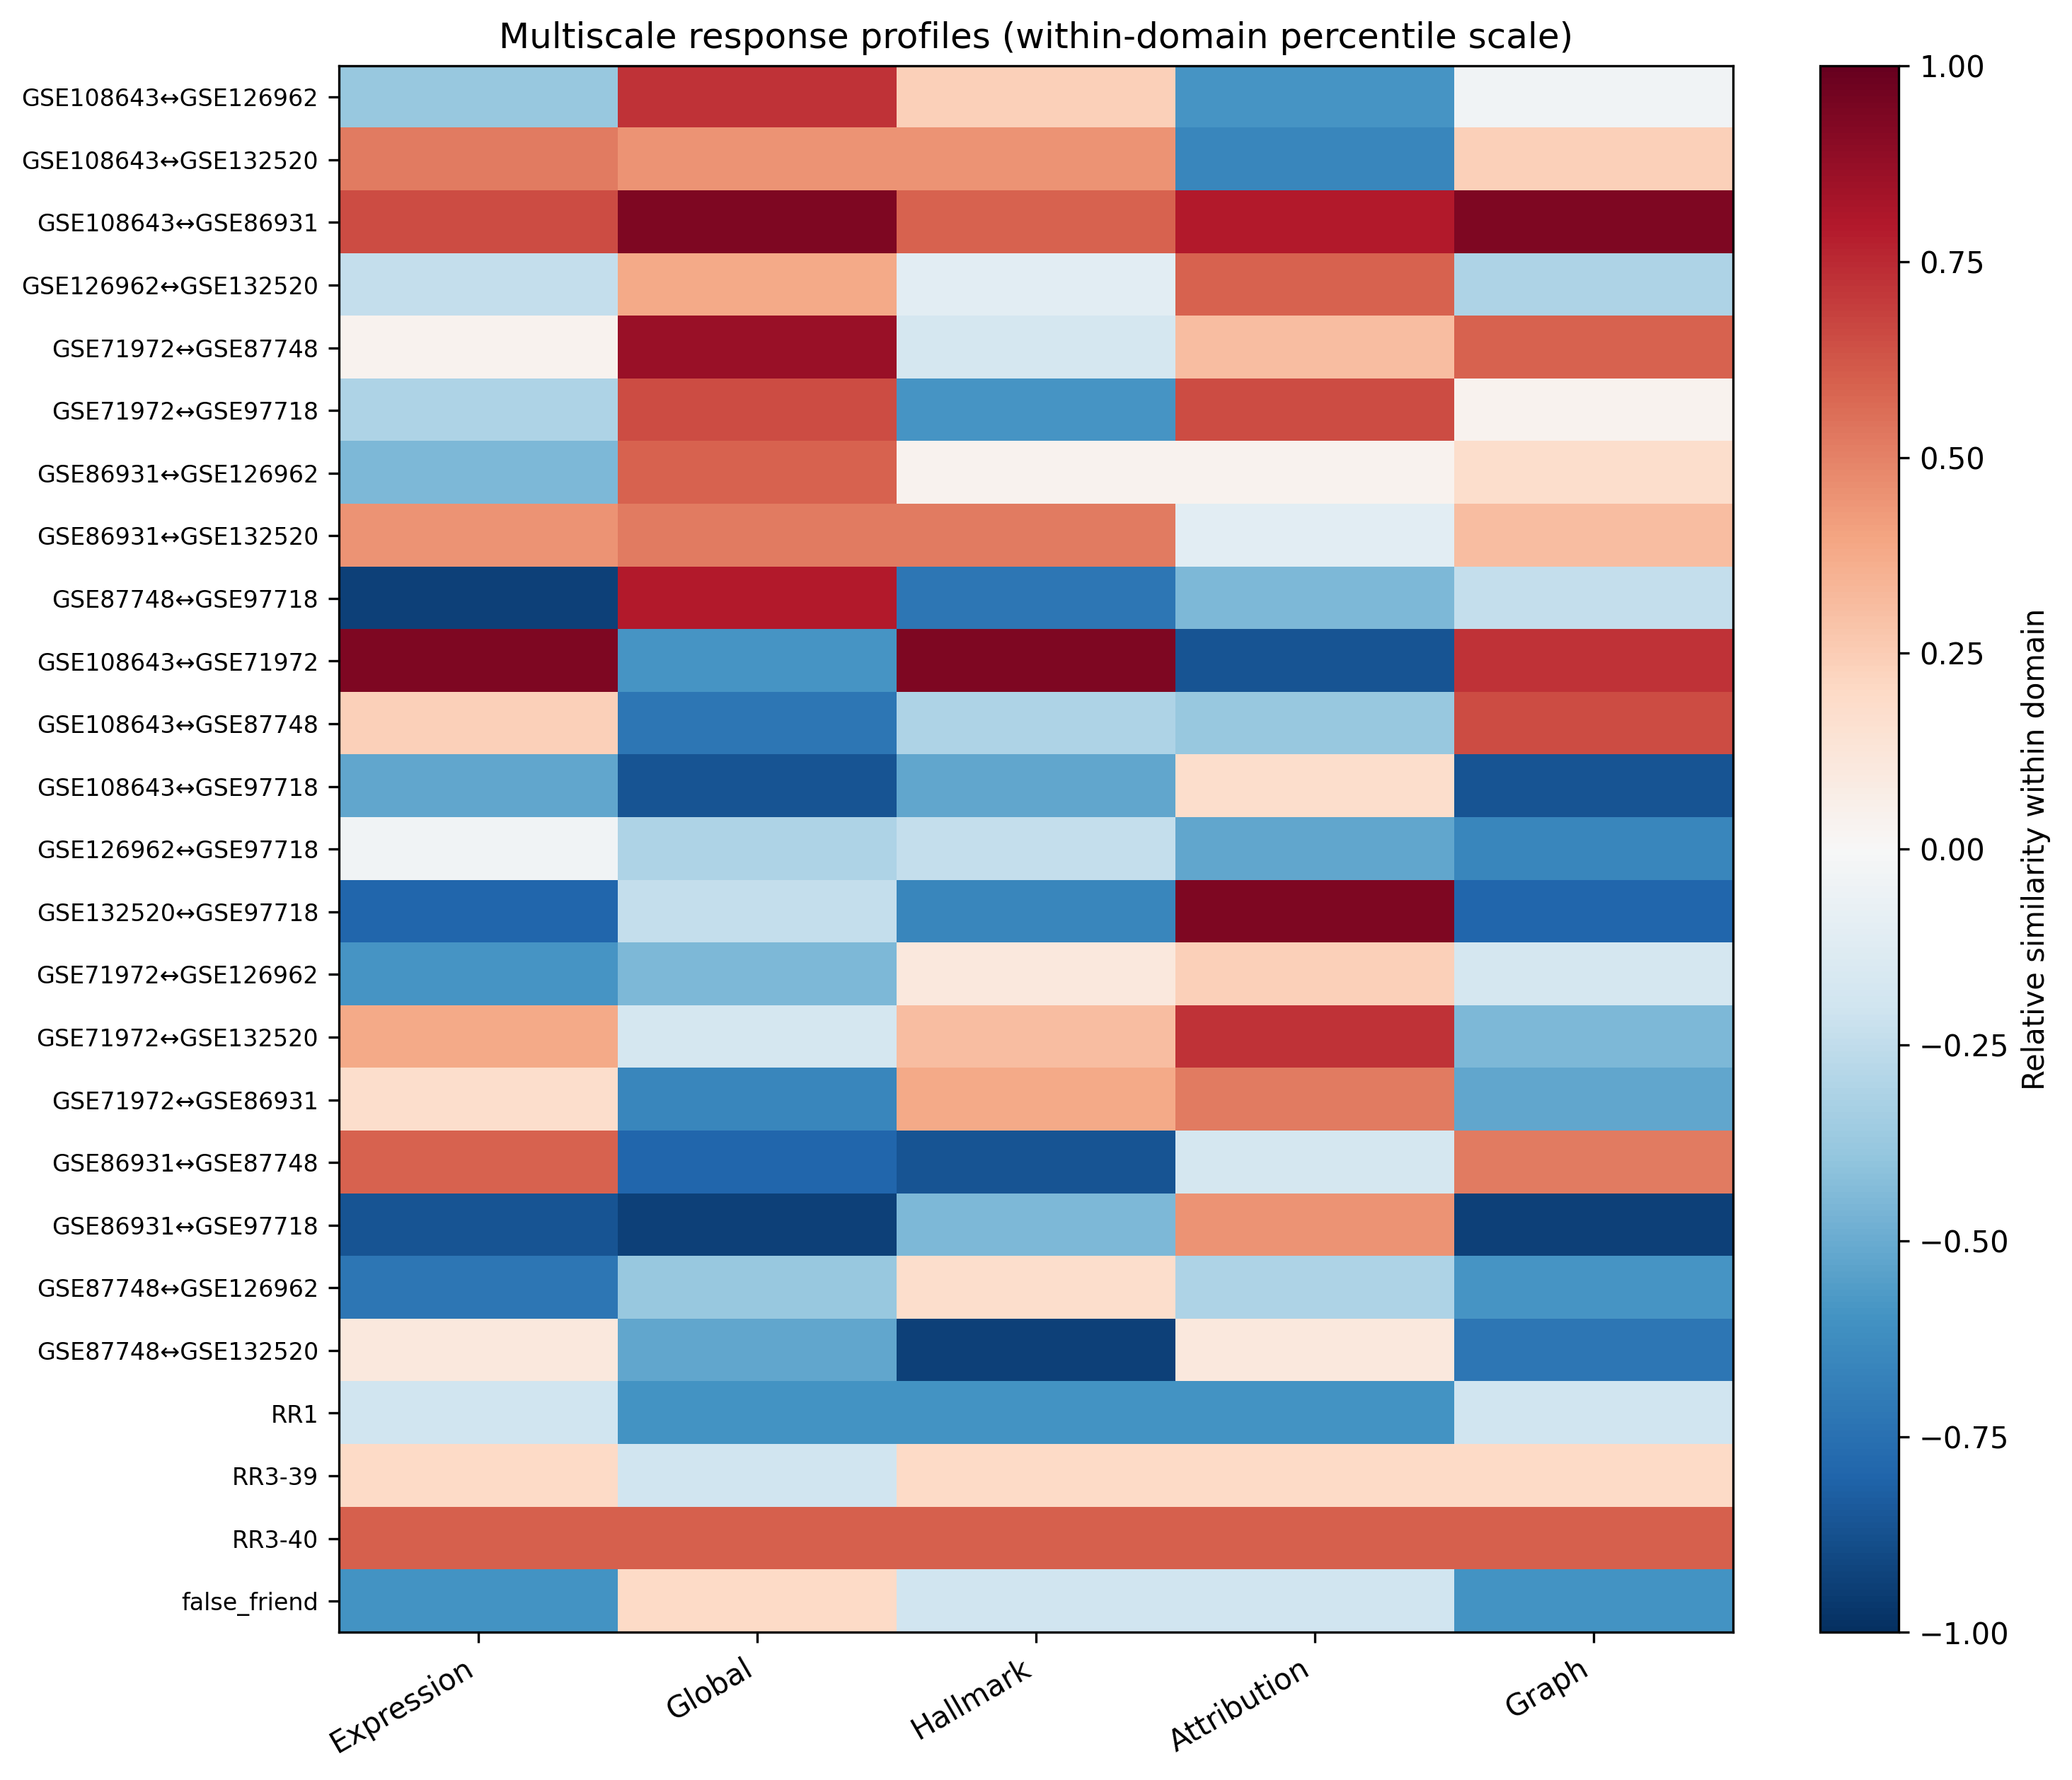

In [7]:
display(Image(filename=str(R / 'figures/multiscale_heatmap.png')))

## Descriptive discrimination

The following AUROC/AUPRC values combine the two true RR technical remeasurements with prespecified same-pattern exercise pairs as positives. The set is small and pairwise observations share contrasts, so these are **descriptive ranking diagnostics**, not inferential performance estimates or a trained classifier.

In [8]:
disc = pd.read_csv(R / 'discrimination/descriptive_discrimination.csv')
display(disc.style.format({'auroc':'{:.3f}','auprc':'{:.3f}'}))

,score,pairs,positives,auroc,auprc,scope
0,global_bridgerna,24,11,0.986,0.986,descriptive; RR stress cases and prespecified exercise groupings
1,global+graph,24,11,0.986,0.984,descriptive; RR stress cases and prespecified exercise groupings
2,global+hallmark,24,11,0.948,0.939,descriptive; RR stress cases and prespecified exercise groupings
3,global+attribution,24,11,0.902,0.883,descriptive; RR stress cases and prespecified exercise groupings
4,all_five,24,11,0.871,0.854,descriptive; RR stress cases and prespecified exercise groupings
5,contextual_graph,24,11,0.790,0.690,descriptive; RR stress cases and prespecified exercise groupings
6,hallmark_program,24,11,0.678,0.623,descriptive; RR stress cases and prespecified exercise groupings
7,expression+attribution,24,11,0.605,0.656,descriptive; RR stress cases and prespecified exercise groupings
8,expression,24,11,0.601,0.557,descriptive; RR stress cases and prespecified exercise groupings
9,attribution,24,11,0.545,0.526,descriptive; RR stress cases and prespecified exercise groupings


## Conclusions

1. True RR3 remeasurements agree across all five scales; RR3-40 is consistently strongest.
2. Global BridgeRNA similarity is highly discriminative across the prespecified exercise groupings, but it can create a specific false friend.
3. Graph and attribution/program layers diagnose *why* a high global similarity should not automatically be interpreted as molecular equivalence.
4. RR1 shows disagreement at multiple biological resolutions, not just a defect in global cosine geometry.
5. The controlled T-cell and ARCHS4/recount3 experiments remain important technical controls, but their units do not support the same five-response-vector calculation.
6. Combining all five components does not automatically improve descriptive discrimination. The value of the framework is resolution and falsification of overbroad global interpretations, not a guaranteed composite-score gain.

**Claim boundary:** multiscale agreement does not establish a shared mechanism, contextual graph edges are not regulatory networks, and none of these analyses demonstrate batch removal.